In [22]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 4
METRICS_NOTES = "Power Transformer + Log"
PCA = False
scaler = 'power' # or 'standard' for StandardScaler



UPDATE_DATABASE = True

LOG_TRANSFORM_COLS = np.array(
    ['number_outpatient', 'number_inpatient', 'number_emergency', 
     'num_medications', 'num_procedures', 'time_in_hospital'
     ])

# Results

In [43]:
from shared_util.fetch import fetch_metric
import pandas as pd

pca_results_df = fetch_metric(run_id=2)
results_df = fetch_metric(run_id=1)

pt_df = fetch_metric(run_id=3)

pt_log_df = fetch_metric(run_id=4)



results_df[results_df['data'] == 'test'].head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,created_at
0,35,1,xgb,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.675963,0.472337,0.128680,0.767159,0.220392,4709.0,883.0,5979.0,268.0,2025-10-27 23:41:10.147287
11,24,1,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674749,0.264465,0.109538,0.920938,0.195789,2071.0,1060.0,8617.0,91.0,2025-10-27 23:23:22.331265
4,31,1,svc,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.674099,0.418954,0.122263,0.805387,0.212298,4033.0,927.0,6655.0,224.0,2025-10-27 23:36:02.302171
7,28,1,sgd,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.669999,0.421995,0.122847,0.805387,0.213177,4069.0,927.0,6619.0,224.0,2025-10-27 23:24:32.414371


In [44]:
from shared_util.pd_util import filter_df

results_df = filter_df(results_df, model=['xgb', 'svc', 'sgd'])


df = pd.concat([pca_results_df, results_df, pt_df, pt_log_df], axis=0)

run_notes = pd.DataFrame({
    "run_id": [1, 2, 3, 4],
    "label": ["log+scaling", "PCA", "pt+no-log", "pt+log"]
})


df_test = filter_df(df, data=['test'])
df_means = df_test.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,1,log+scaling,0.800000,8.0,0.673354,0.215289,0.124596,0.792644,0.437762
1,3,pt+no-log,0.533333,12.0,0.672461,0.210153,0.120568,0.821604,0.397838
2,4,pt+log,0.466667,13.0,0.672828,0.208591,0.119499,0.824500,0.390067
3,2,PCA,0.200000,17.0,0.623478,0.200012,0.113691,0.866203,0.311991



=== Top 4 by roc_auc ===


,run_id,label,roc_auc
0,1,log+scaling,0.673354
2,4,pt+log,0.672828
1,3,pt+no-log,0.672461
3,2,PCA,0.623478



=== Top 4 by f1 ===


...

,run_id,label,precision
0,1,log+scaling,0.124596
1,3,pt+no-log,0.120568
2,4,pt+log,0.119499
3,2,PCA,0.113691



=== Top 4 by recall ===


,run_id,label,recall
3,2,PCA,0.866203
2,4,pt+log,0.824500
1,3,pt+no-log,0.821604
0,1,log+scaling,0.792644



=== Top 4 by accuracy ===


,run_id,label,accuracy
0,1,log+scaling,0.437762
1,3,pt+no-log,0.397838
2,4,pt+log,0.390067
3,2,PCA,0.311991


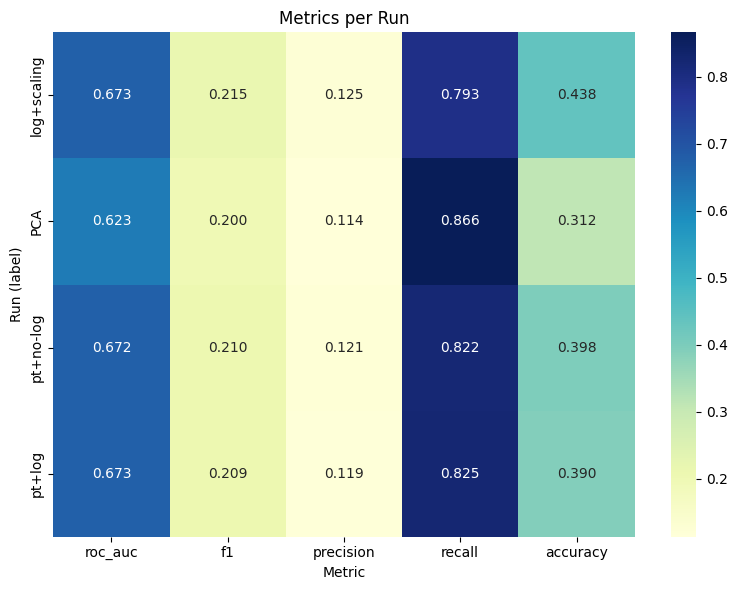

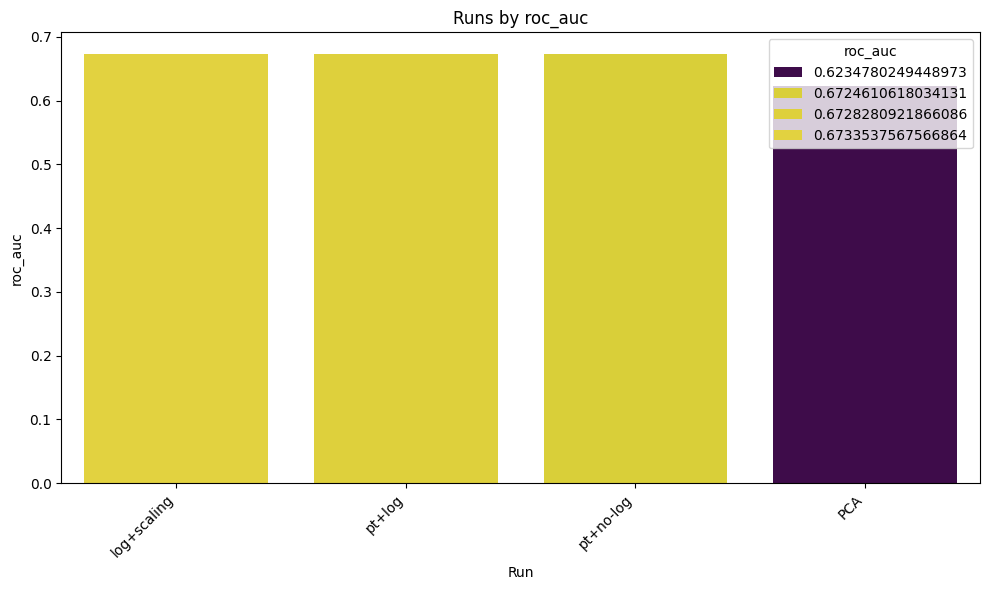

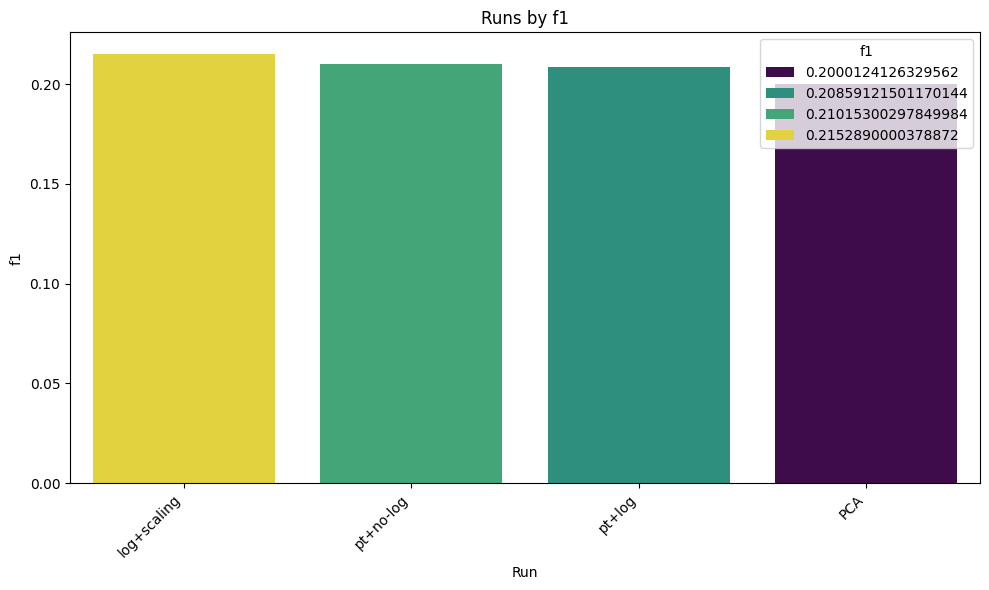

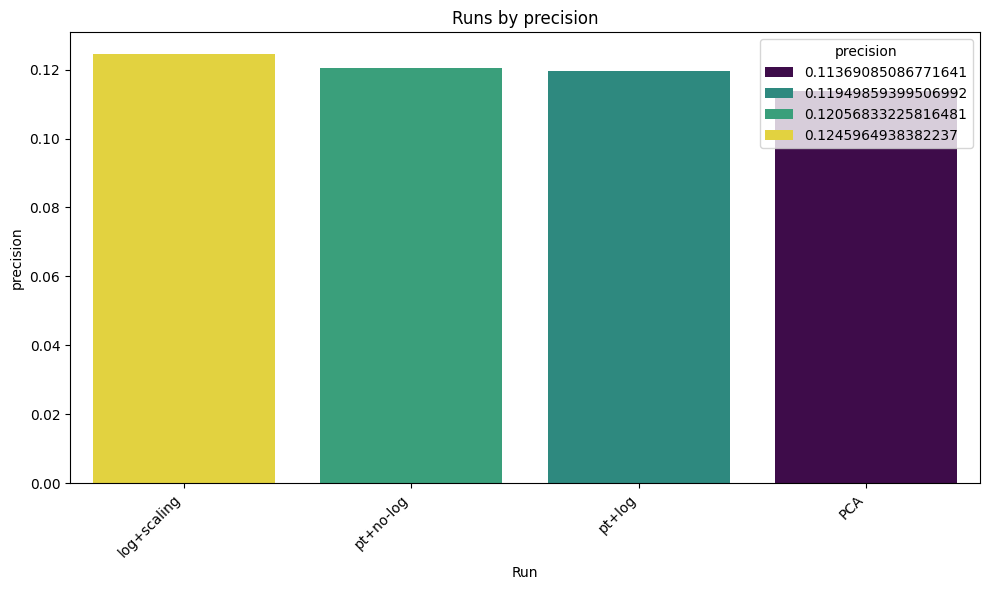

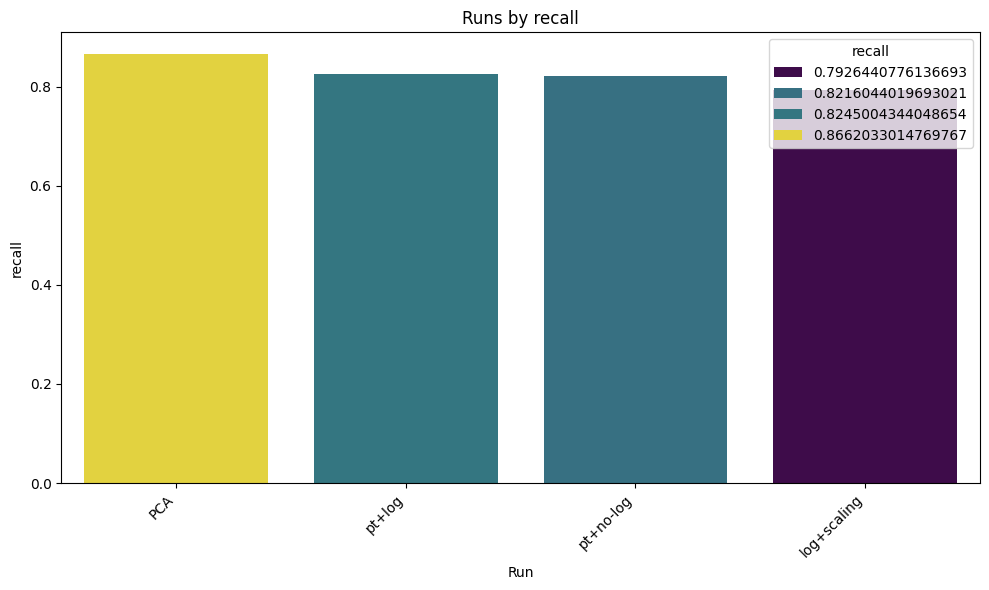

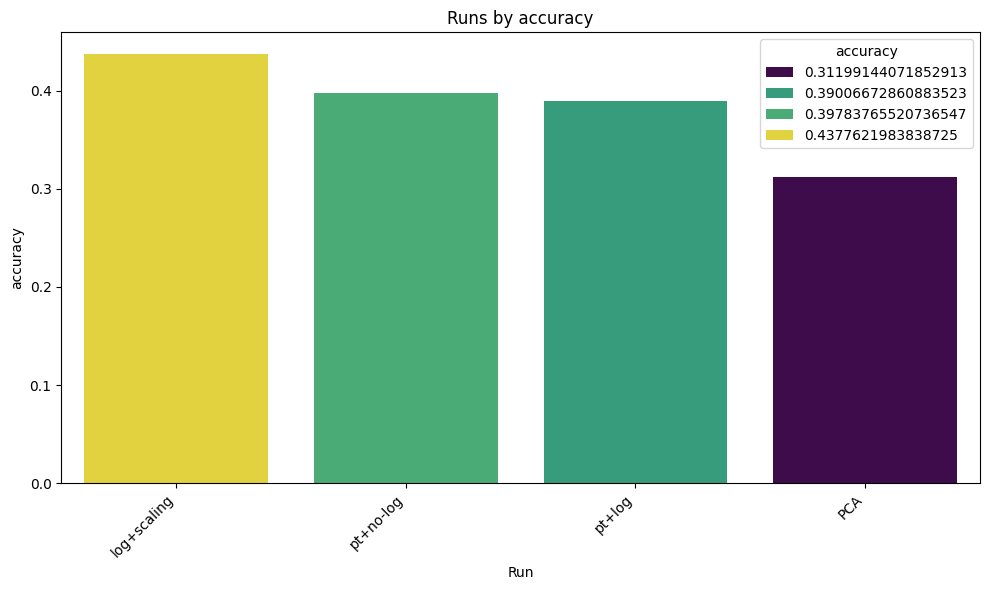

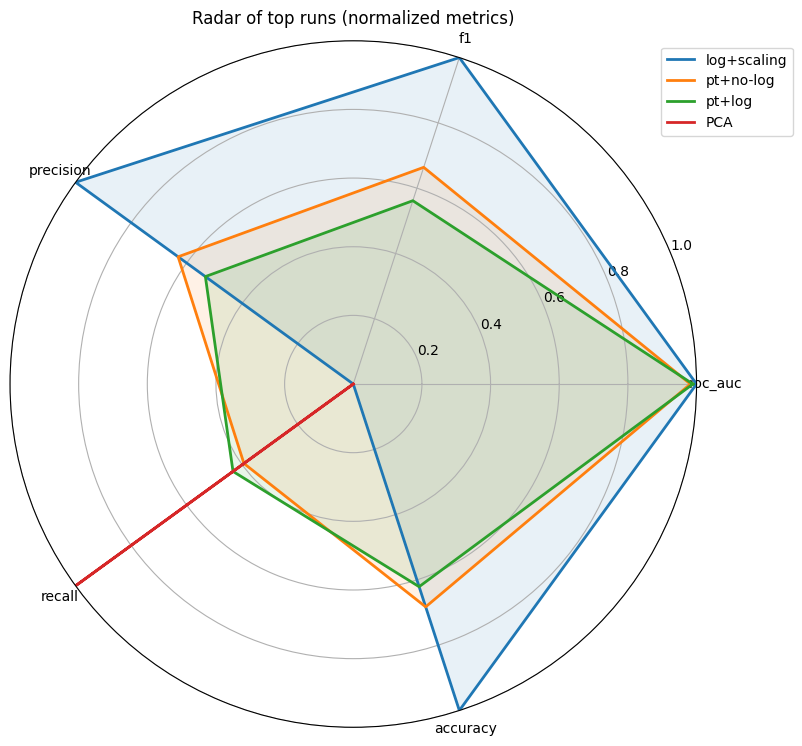

,run_id,label,roc_auc,f1,precision,recall,accuracy,rank_roc_auc,rank_f1,rank_precision,rank_recall,rank_accuracy,rank_sum,overall_score
0,1,log+scaling,0.673354,0.215289,0.124596,0.792644,0.437762,1.0,1.0,1.0,4.0,1.0,8.0,0.800000
1,3,pt+no-log,0.672461,0.210153,0.120568,0.821604,0.397838,3.0,2.0,2.0,3.0,2.0,12.0,0.533333
2,4,pt+log,0.672828,0.208591,0.119499,0.824500,0.390067,2.0,3.0,3.0,2.0,3.0,13.0,0.466667
3,2,PCA,0.623478,0.200012,0.113691,0.866203,0.311991,4.0,4.0,4.0,1.0,4.0,17.0,0.200000


In [45]:
from shared_util.metrics.compare_linear import compare_runs

compare_runs(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)

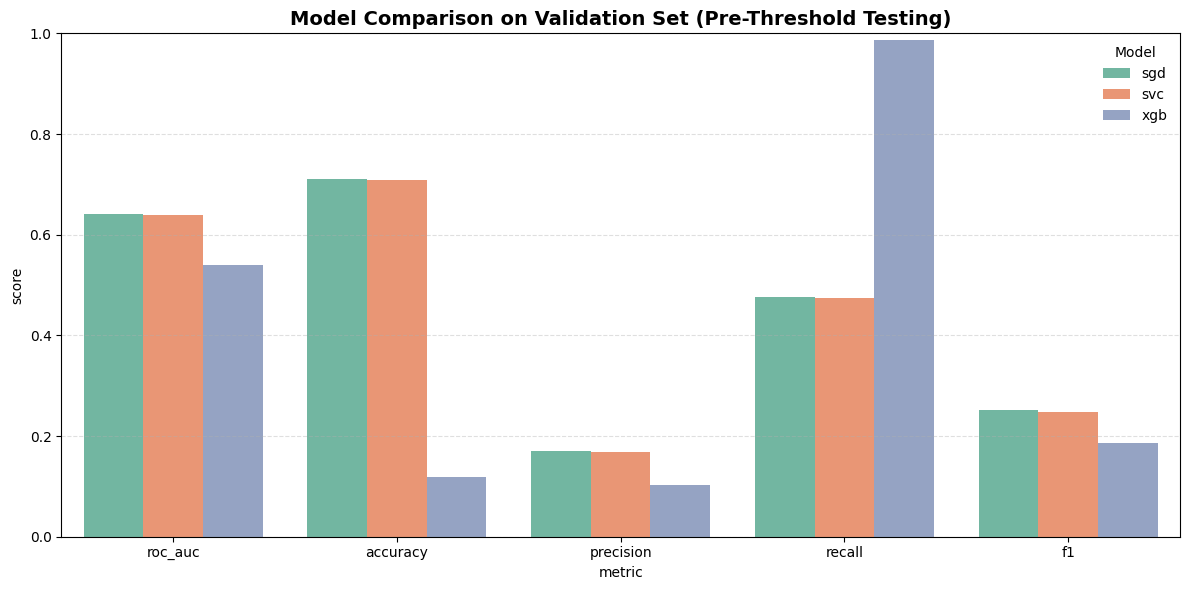

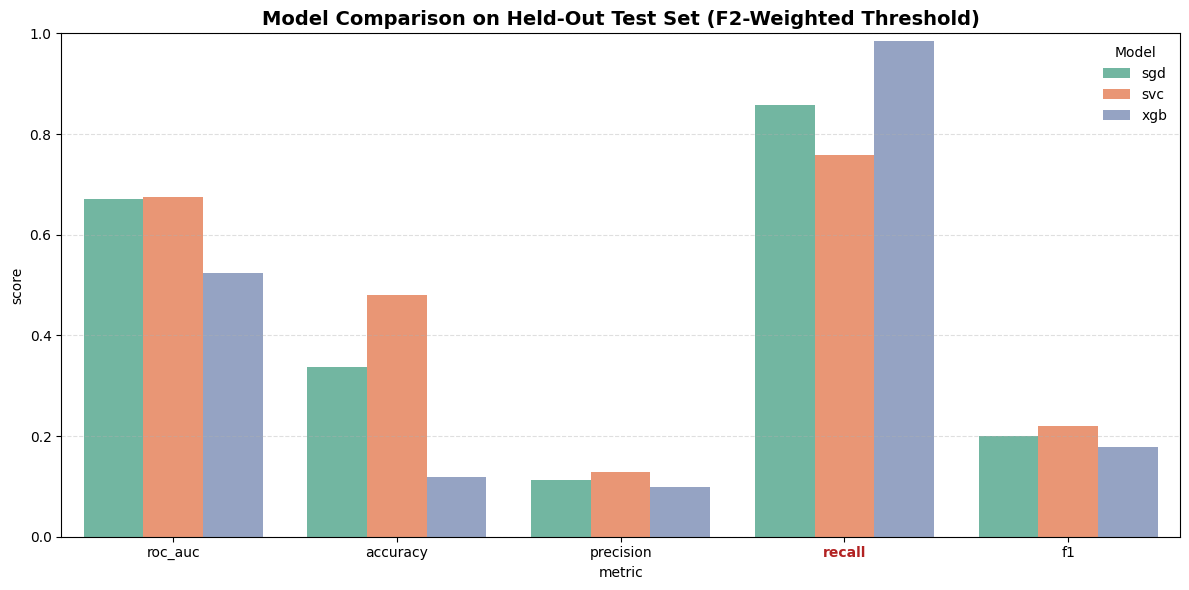

In [22]:
from shared_util.results.results import summary_by_auc, summary_by_recall, plot_metrics

plot_metrics(pca_results_df, METRICS_DB_ID)

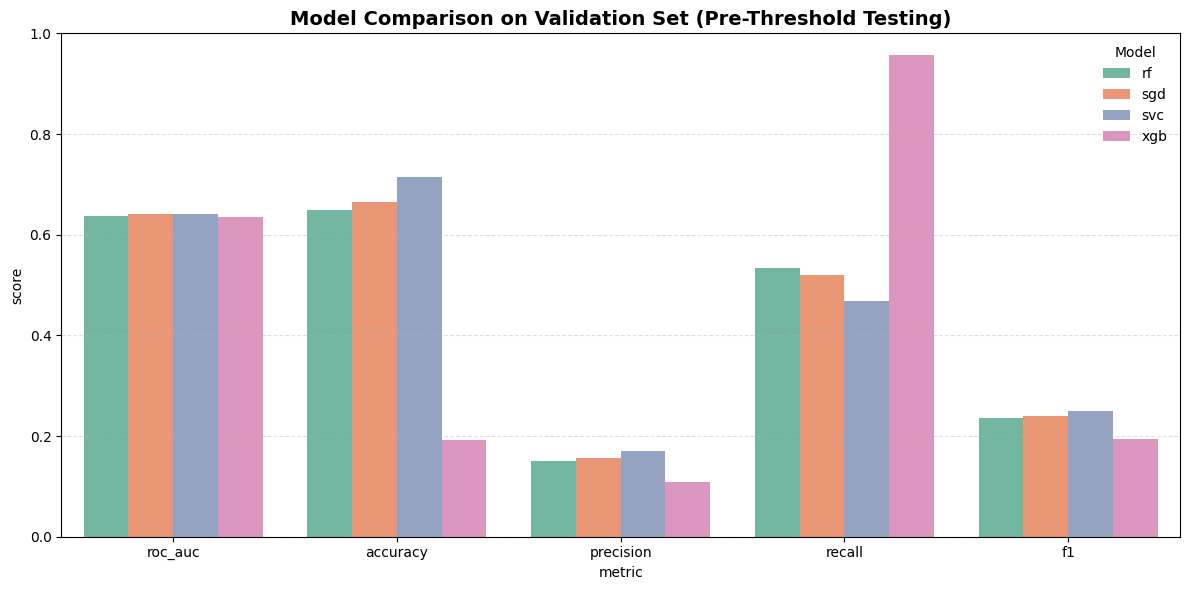

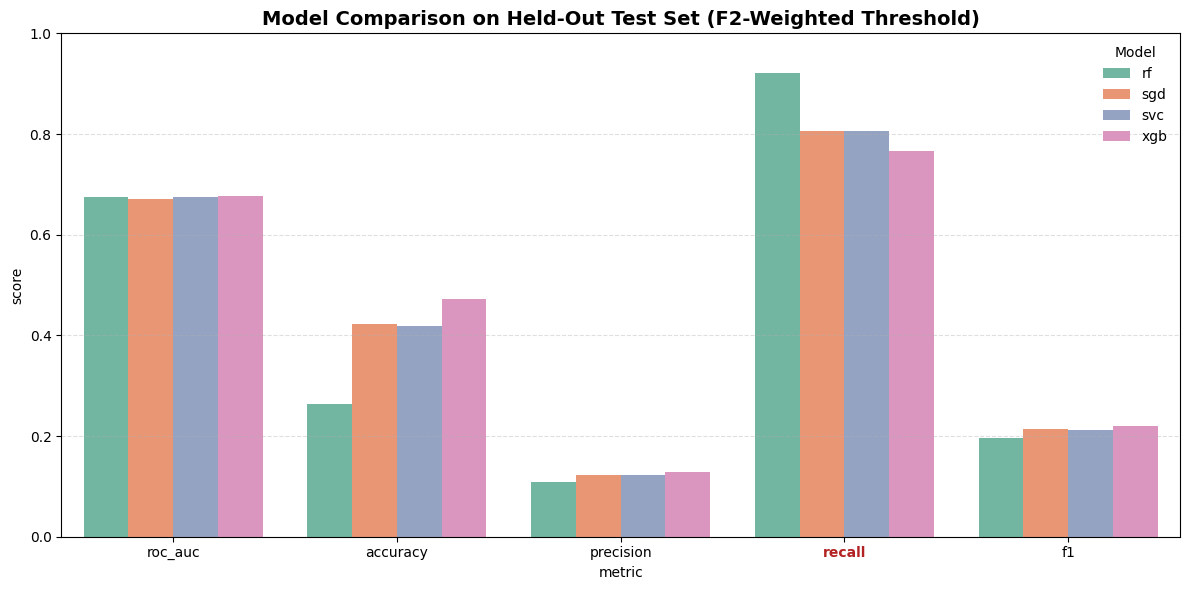

In [23]:
plot_metrics(results_df, 1)

In [ ]:
print('--pca--')
summary_by_auc(pca_results_df, plot_id=METRICS_DB_ID)
summary_by_recall(pca_results_df)

print('--no pca--')
summary_by_auc(results_df, plot_id=1)
summary_by_recall(results_df)



--pca--
Models by ROC_AUC


,model,roc_auc
0,svc,0.675
1,sgd,0.671
10,xgb,0.525


Models by Recall


,model,recall
7,xgb,0.984
0,sgd,0.857
4,svc,0.758


--no pca--
Models by ROC_AUC


,model,roc_auc
0,xgb,0.676
1,rf,0.675
2,svc,0.674
3,sgd,0.670


Models by Recall


,model,recall
11,rf,0.921
7,sgd,0.805
4,svc,0.805
0,xgb,0.767


### Hyperparameter Display

In [23]:
from shared_util.fetch import fetch_hyperparams
import pandas as pd
import ast
import re

h_params_df = fetch_hyperparams(run_id=METRICS_DB_ID)

h_params_df.head(5)


_np_wrapper = re.compile(r"np\.(?:float|int)\d+\(([^)]+)\)")

def parse_hyperparams(text: str) -> pd.DataFrame:
    cleaned = _np_wrapper.sub(r"\1", text)
    params = ast.literal_eval(cleaned)

    def normalize(value):
        if isinstance(value, np.generic):
            return value.item()
        return value

    data = {k: normalize(v) for k, v in params.items()}
    return pd.DataFrame(data.items(), columns=["param", "value"])

for row in h_params_df.itertuples():
    print(f'Model: {row.model}')
    display(parse_hyperparams(row.hyperparam_text)) # type: ignore


Model: xgb


,param,value
0,model__colsample_bytree,5.325258e-01
1,model__gamma,4.744428e+00
2,model__learning_rate,2.900333e-01
3,model__max_depth,3.000000e+00
4,model__min_child_weight,9.000000e+00
5,model__n_estimators,7.640000e+02
6,model__reg_alpha,4.132918e-07
7,model__reg_lambda,5.285382e-02
8,model__scale_pos_weight,1.614304e+01
9,model__subsample,8.049983e-01


Model: svc


,param,value
0,model__C,4.418442
1,model__class_weight,balanced
2,model__gamma,0.001
3,model__kernel,rbf
4,model__shrinking,False


Model: sgd


,param,value
0,model__tol,0.001
1,model__shuffle,True
2,model__penalty,l2
3,model__max_iter,100
4,model__loss,hinge
5,model__learning_rate,adaptive
6,model__l1_ratio,0.5
7,model__eta0,0.0003
8,model__class_weight,None
9,model__average,True


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

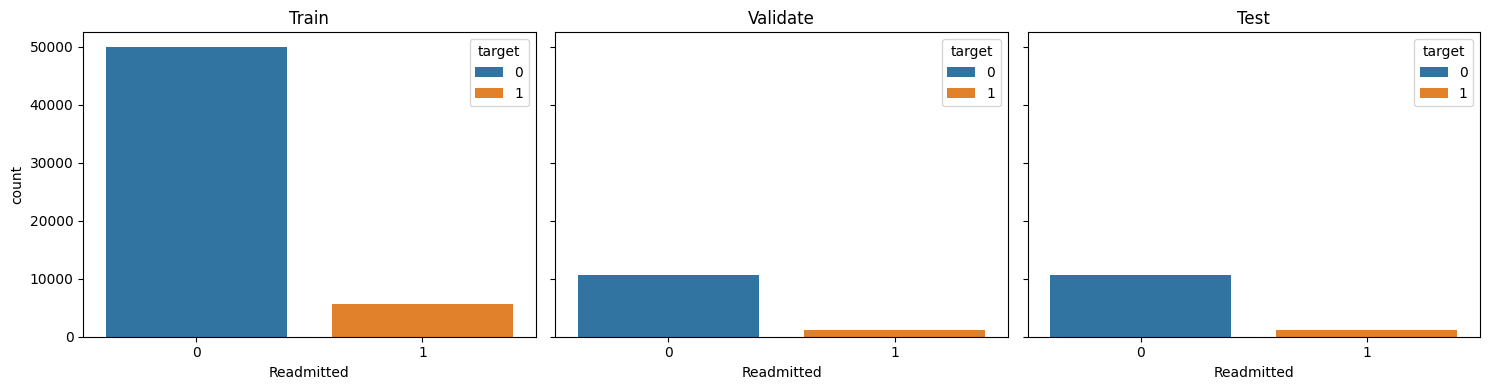

In [ ]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False # no interaction terms for tree models
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [6]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.593 0.592 0.597 0.6   0.589]
mean roc_auc score: , 0.594
connected to database
-----Undersample Baseline-----
roc_auc score per fold:  [0.654 0.635 0.624 0.653 0.632]
mean roc_auc score: , 0.640
Duration: 0 hrs, 0 mins, 19.0 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
6,number_inpatient,0.067655,0.009661
5,number_emergency,0.006267,0.001169
3,num_medications,0.003834,0.003512
7,number_diagnoses,0.003263,0.003882
0,time_in_hospital,0.002859,0.002259
2,num_procedures,0.002400,0.002274
15,diag1_group_respiratory,0.002164,0.001035
1,num_lab_procedures,0.002108,0.001784
37,specialty_cat_cardiology,0.002038,0.000482
12,diag1_group_musculoskeletal,0.001686,0.000573


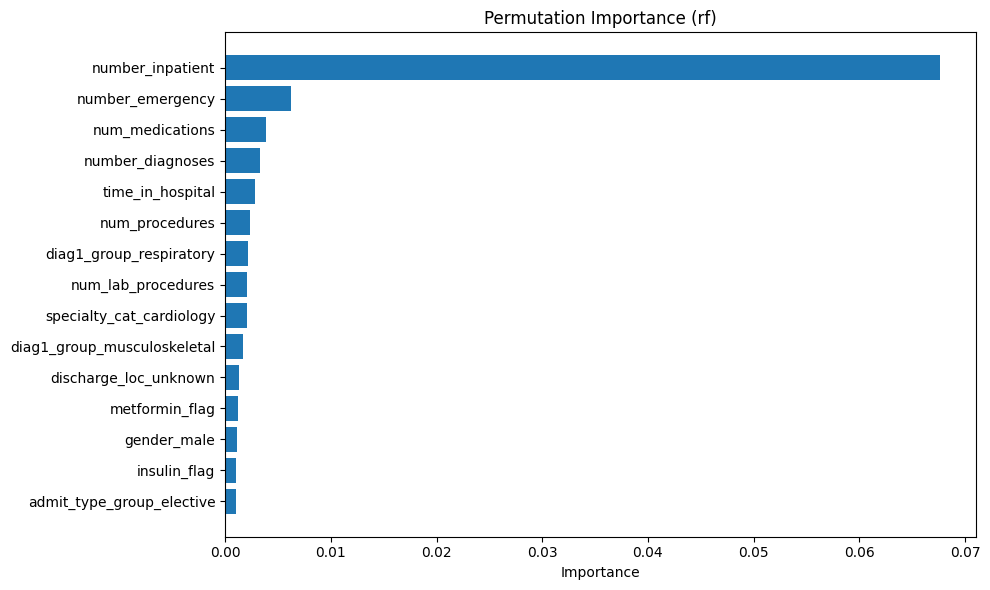

Duration: 0 hrs, 0 mins, 42.3 secs


In [7]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [8]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Best ROC_AUC (cv): 0.658743270492685
Best params: {'model__oob_score': False, 'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_features': 0.2, 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}
logged hyperparameters
Duration: 0 hrs, 0 mins, 32.2 secs


In [9]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6369706741016923
Accuracy:      0.6484578536011429
F1 score:      0.23598173515981735
Precision:     0.15139442231075698
Recall:        0.5347682119205298

Confusion matrix:

TN: 7070, FP: 3621, FN: 562, TP: 646

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.77     10691
           1       0.15      0.53      0.24      1208

    accuracy                           0.65     11899
   macro avg       0.54      0.60      0.50     11899
weighted avg       0.85      0.65      0.72     11899



Best threshold (F2): 0.3734
Precision: 0.112  Recall: 0.913  F2: 0.376


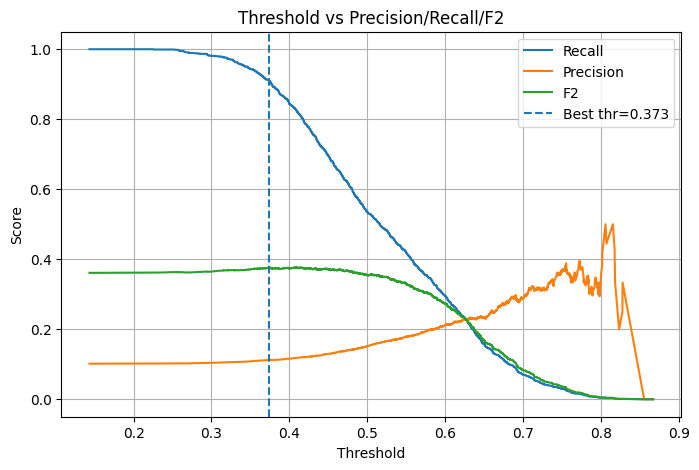

ROC_AUC:     0.674748705239391
Accuracy:      0.2644649041304164
F1 score:      0.1957886959734023
Precision:     0.10953807998346594
Recall:        0.9209383145091226

Confusion matrix:

TN: 2071, FP: 8617, FN: 91, TP: 1060

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.19      0.32     10688
           1       0.11      0.92      0.20      1151

    accuracy                           0.26     11839
   macro avg       0.53      0.56      0.26     11839
weighted avg       0.88      0.26      0.31     11839



In [10]:
model_pipe.test(
    use_f2_threshold=True,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

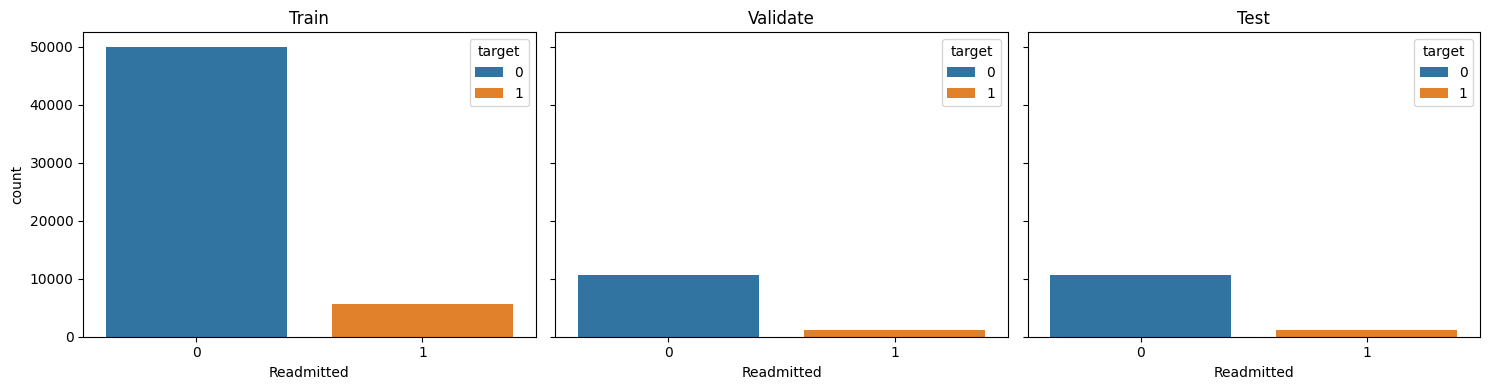

In [23]:
model = 'sgd' #SGDClassifier


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True
)



,feature,importance_mean,importance_std
6,number_inpatient,0.056166,0.012715
15,diag1_group_respiratory,0.015329,0.008270
66,i_hosp_time__diag1_group_other,0.008691,0.011297
69,i_hosp_time__specialty_cat_internal_medicine,0.006822,0.005060
67,i_hosp_time__diag1_group_respiratory,0.006214,0.004073
5,number_emergency,0.005800,0.001585
54,diabetesMed_flag,0.004535,0.003244
0,time_in_hospital,0.004191,0.005440
7,number_diagnoses,0.003187,0.002937
14,diag1_group_other,0.003058,0.003103


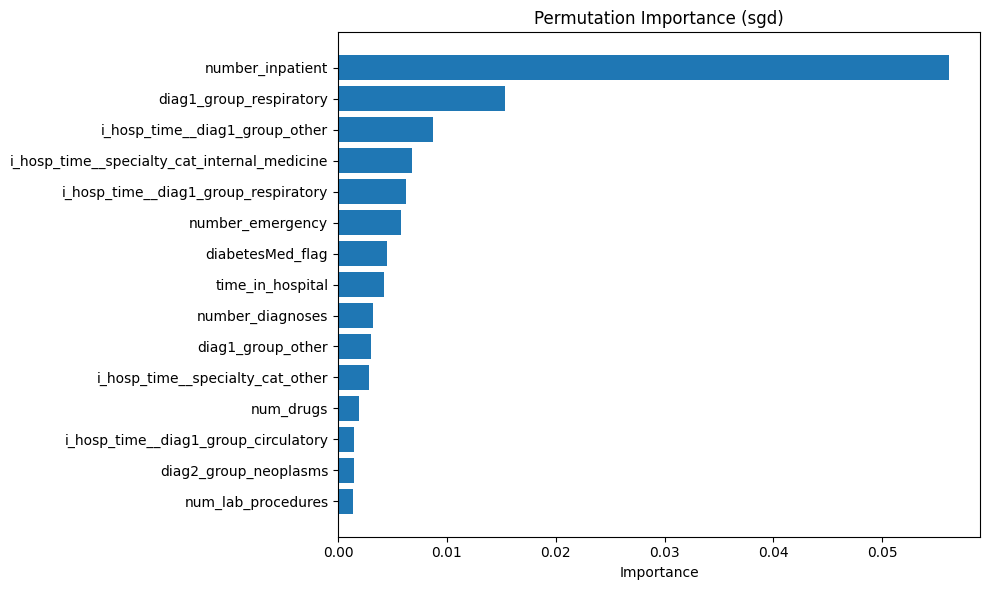

Duration: 0 hrs, 0 mins, 15.8 secs


In [24]:
if not PCA:
    sgd_pipe.permute_importance()

In [25]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.566 0.575 0.544 0.558 0.541]
mean roc_auc score: , 0.557
-----Undersample Baseline-----
roc_auc score per fold:  [0.597 0.581 0.61  0.59  0.606]
mean roc_auc score: , 0.597
Duration: 0 hrs, 0 mins, 13.8 secs


In [26]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6553530313026933
Best params: {'model__tol': 0.001, 'model__shuffle': True, 'model__penalty': 'l2', 'model__max_iter': 100, 'model__loss': 'hinge', 'model__learning_rate': 'adaptive', 'model__l1_ratio': 0.5, 'model__eta0': 0.0003, 'model__class_weight': None, 'model__average': True, 'model__alpha': 0.0001}
logged hyperparameters
Duration: 0 hrs, 0 mins, 42.2 secs


In [27]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.6400728687433448
Accuracy:      0.6787124968484747
F1 score:      0.23829448097230524
Precision:     0.1569141957491472
Recall:        0.49503311258278143

Confusion matrix:

TN: 7478, FP: 3213, FN: 610, TP: 598

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.70      0.80     10691
           1       0.16      0.50      0.24      1208

    accuracy                           0.68     11899
   macro avg       0.54      0.60      0.52     11899
weighted avg       0.85      0.68      0.74     11899



Best threshold (F2): -0.9373
Precision: 0.117  Recall: 0.867  F2: 0.380


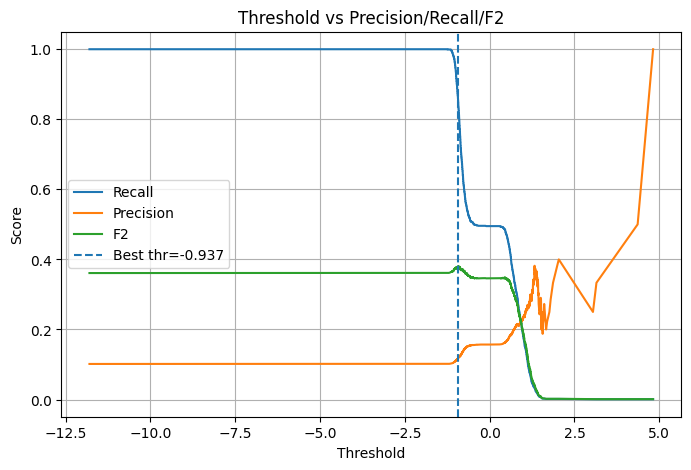

ROC_AUC:     0.6693293744830062
Accuracy:      0.3294197145029141
F1 score:      0.20122748767481638
Precision:     0.1137915339098771
Recall:        0.8688097306689835

Confusion matrix:

TN: 2900, FP: 7788, FN: 151, TP: 1000

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.27      0.42     10688
           1       0.11      0.87      0.20      1151

    accuracy                           0.33     11839
   macro avg       0.53      0.57      0.31     11839
weighted avg       0.87      0.33      0.40     11839



In [28]:
sgd_pipe.test(show_duration_info=False)

# Support Vector Classifier

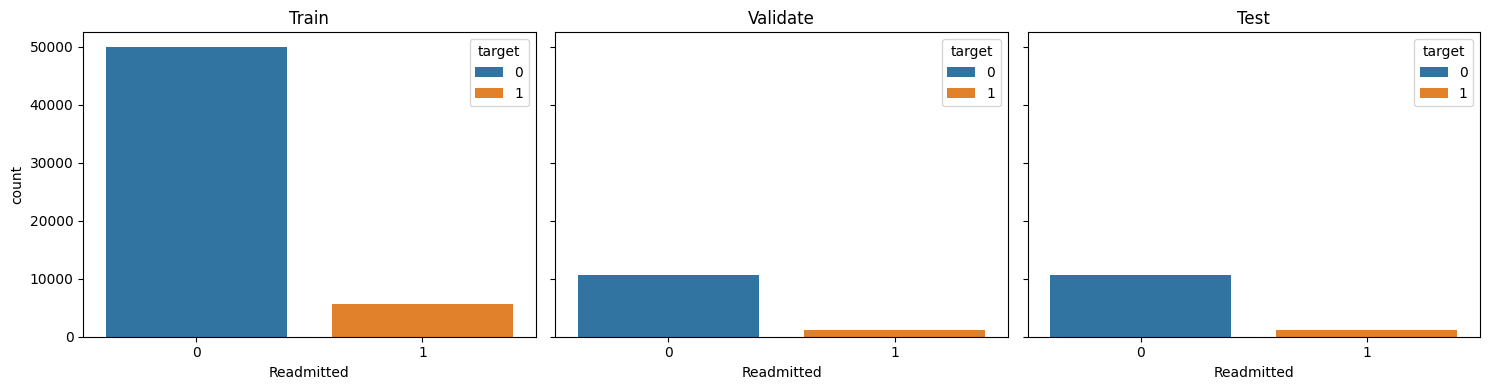

In [29]:

svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True
)

In [30]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.638 0.633 0.645 0.66  0.632]
mean roc_auc score: , 0.642
Duration: 0 hrs, 0 mins, 15.3 secs


In [31]:
# slow
# svc_pipe.permute_importance()

In [32]:
from scipy.stats import loguniform


# limited param search due to computation time
svc_param_grid = {
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],     
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6549978153955057
Best params: {'model__C': np.float64(0.6317967091932509), 'model__gamma': 0.001}
logged hyperparameters
Duration: 0 hrs, 10 mins, 28.5 secs


In [33]:
svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.637792061900181
Accuracy:      0.6777880494159173
F1 score:      0.23868149324861002
Precision:     0.15700104493207942
Recall:        0.49751655629139074

Confusion matrix:

TN: 7464, FP: 3227, FN: 607, TP: 601

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.70      0.80     10691
           1       0.16      0.50      0.24      1208

    accuracy                           0.68     11899
   macro avg       0.54      0.60      0.52     11899
weighted avg       0.85      0.68      0.74     11899



Best threshold (F2): -0.8542
Precision: 0.121  Recall: 0.809  F2: 0.378


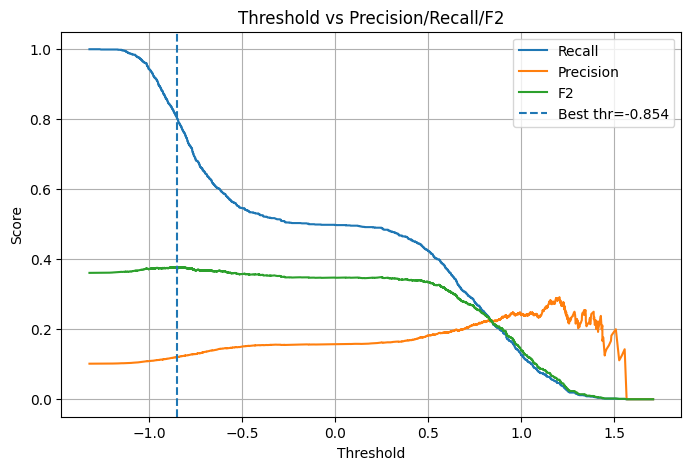

ROC_AUC:     0.6719137745360713
Accuracy:      0.3934453923473266
F1 score:      0.20748261781260346
Precision:     0.11883691529709228
Recall:        0.8166811468288445

Confusion matrix:

TN: 3718, FP: 6970, FN: 211, TP: 940

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.35      0.51     10688
           1       0.12      0.82      0.21      1151

    accuracy                           0.39     11839
   macro avg       0.53      0.58      0.36     11839
weighted avg       0.87      0.39      0.48     11839



In [34]:
svc_pipe.test()

# XGBoost

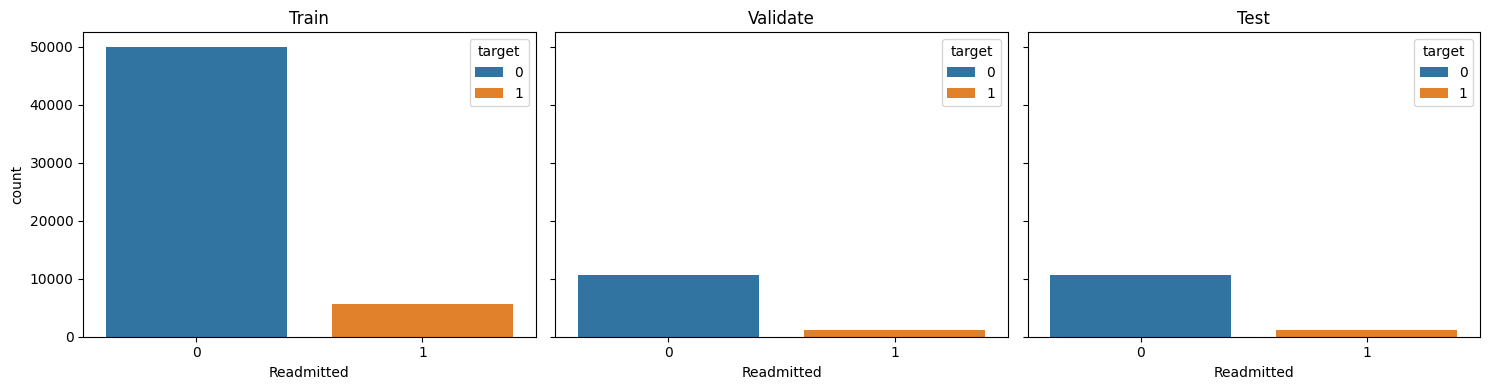

In [35]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=False,
    log_transform_cols=LOG_TRANSFORM_COLS,
    use_pca=PCA,
    scaler=None
)

In [36]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.627 0.622 0.613 0.623 0.613]
mean roc_auc score: , 0.620
-----Undersample Baseline-----
roc_auc score per fold:  [0.624 0.621 0.614 0.635 0.617]
mean roc_auc score: , 0.622
Duration: 0 hrs, 0 mins, 12.5 secs


,feature,importance_mean,importance_std
6,number_inpatient,0.062349,0.008398
3,num_medications,0.008727,0.001492
1,num_lab_procedures,0.007647,0.002758
5,number_emergency,0.006285,0.002415
0,time_in_hospital,0.004077,0.001113
7,number_diagnoses,0.003826,0.004539
37,specialty_cat_cardiology,0.002723,0.001296
15,diag1_group_respiratory,0.002660,0.002808
58,num_drugs,0.002467,0.000868
12,diag1_group_musculoskeletal,0.002421,0.000814


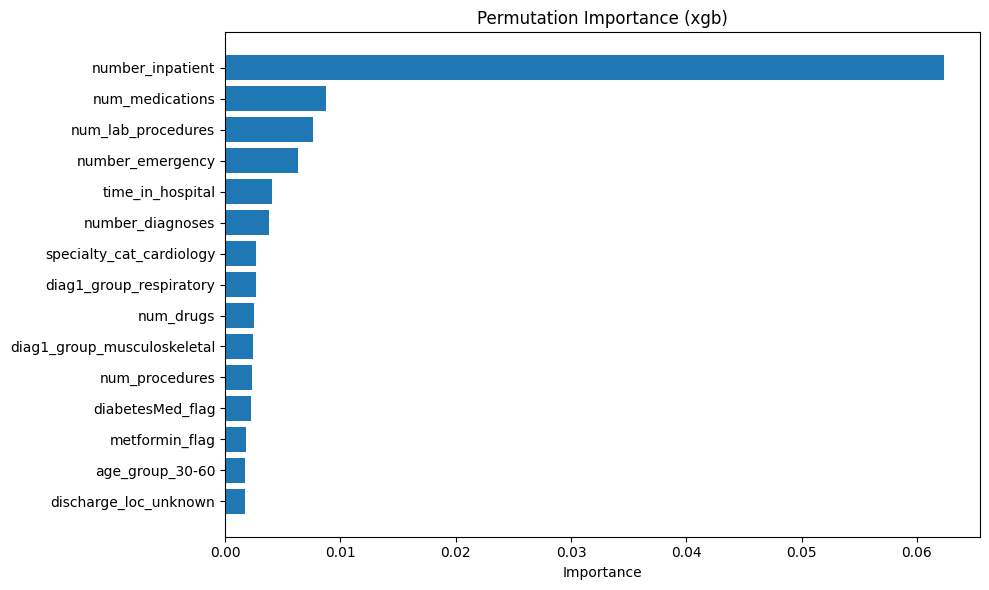

Duration: 0 hrs, 0 mins, 20.8 secs


In [37]:
if not PCA:
    xgb_pipe.permute_importance()

In [38]:
from scipy.stats import randint, uniform, loguniform

approx_spw = float(8.9494) # from data exploration aprox inverse of class balance


param_dist = {
    'model__n_estimators': randint(1000, 2500),
    'model__learning_rate': uniform(0.01, 0.10),
    'model__max_depth': randint(4, 15),
    'model__min_child_weight': randint(1, 8),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': [approx_spw],
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6566104552458178
Best params: {'model__colsample_bytree': np.float64(0.587477463547968), 'model__gamma': np.float64(4.910841716647178), 'model__learning_rate': np.float64(0.06166358912710143), 'model__max_depth': 4, 'model__min_child_weight': 2, 'model__n_estimators': 1896, 'model__reg_alpha': np.float64(4.4845552058286884e-08), 'model__reg_lambda': np.float64(4.916400722913763), 'model__scale_pos_weight': 8.9494, 'model__subsample': np.float64(0.9502090285816652)}
logged hyperparameters
Duration: 0 hrs, 8 mins, 17.3 secs


In [39]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.6405331184675357
Accuracy:      0.10337003109505001
F1 score:      0.184638899503248
Precision:     0.10170918582133535
Recall:        1.0

Confusion matrix:

TN: 22, FP: 10669, FN: 0, TP: 1208

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.00      0.00     10691
           1       0.10      1.00      0.18      1208

    accuracy                           0.10     11899
   macro avg       0.55      0.50      0.09     11899
weighted avg       0.91      0.10      0.02     11899



Best threshold (F2): 0.8615
Precision: 0.125  Recall: 0.765  F2: 0.379


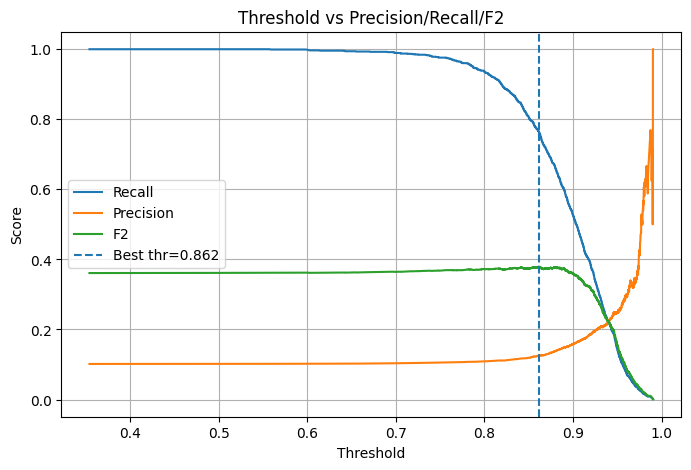

ROC_AUC:     0.6772411275407482
Accuracy:      0.4473350789762649
F1 score:      0.21706353954768456
Precision:     0.12586733277824036
Recall:        0.788010425716768

Confusion matrix:

TN: 4389, FP: 6299, FN: 244, TP: 907

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.41      0.57     10688
           1       0.13      0.79      0.22      1151

    accuracy                           0.45     11839
   macro avg       0.54      0.60      0.40     11839
weighted avg       0.87      0.45      0.54     11839



In [40]:
xgb_pipe.test()

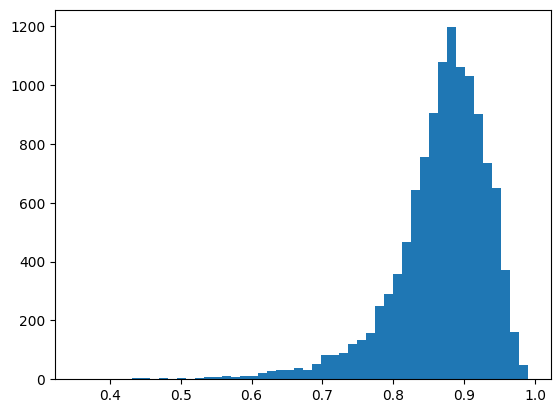

In [41]:
import matplotlib.pyplot as plt
from shared_util.dataio import load_csv



df = load_csv('cleaned')
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
plt.hist(xgb_pipe.randomized_search.best_estimator_.predict_proba(X_validate)[:,1], bins=50) #type: ignore
plt.show()
